In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ==========================================
#   BASELINE SCRIPT FOR INCLUSIVE REWRITING
#   (Zero-shot, Few-shot, CoT, FS+CoT, Super-Prompt)
# ==========================================

!pip install openai pandas

import openai
import pandas as pd

# ==========================================
# 1. Insert your API Key here
# ==========================================

MODEL = "gpt-4o-mini"


# ==========================================
# 2. LLM Helper Function
# ==========================================
def call_llm(prompt, max_tokens=350):
    response = openai.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": prompt}],
        max_tokens=max_tokens,
        temperature=0.3
    )
    return response.choices[0].message.content.strip()


# ==========================================
# 3. BASELINE DEFINITIONS
# ==========================================

# ----- Baseline 1: Zero-Shot -----
def baseline_zero_shot(text):
    prompt = f"""
Rewrite the following sentence in a fully inclusive, respectful, and bias-free way:

{text}
"""
    return call_llm(prompt)


# ----- Shared Few-Shot Examples -----
FEW_SHOT = """
Example 1:
Original: "The old man can't keep up with technology."
Inclusive: "He is still learning current technologies."

Example 2:
Original: "She's just a female engineer."
Inclusive: "She is an engineer."

Example 3:
Original: "People from poor neighborhoods lack discipline."
Inclusive: "Access to opportunities varies based on resources and environment."
"""


# ----- Baseline 2: Few-Shot Instruction -----
def baseline_few_shot(text):
    prompt = FEW_SHOT + f"""

Rewrite the following sentence inclusively:

{text}
"""
    return call_llm(prompt)


# ----- Baseline 3: Chain-of-Thought Reasoning -----
def baseline_cot(text):
    prompt = f"""
Think step by step.

1. Identify biased, discriminatory, or stereotypical language.
2. Explain why it is non-inclusive.
3. Produce a fully inclusive rewrite while preserving meaning.

Sentence: {text}

Step-by-step reasoning:
"""
    return call_llm(prompt)


# ----- Baseline 4: Few-Shot + Chain-of-Thought -----
def baseline_fewshot_cot(text):
    prompt = FEW_SHOT + f"""

Now think step by step:
1. Detect bias
2. Explain the issues
3. Rewrite inclusively with neutral tone

Sentence: {text}

Step-by-step reasoning:
"""
    return call_llm(prompt)


# ----- Baseline 5 (Reviewer-Required): Monolithic Super-Prompt -----
def baseline_super_prompt(text):
    prompt = f"""
You are a single expert responsible for performing ALL tasks normally done by multiple specialists.

Your goal is to rewrite the sentence by satisfying ALL of the following in ONE generation:

• Remove bias, stereotypes, and discriminatory language
• Apply inclusive and person-first wording
• Maintain neutrality and objectivity
• Preserve meaning unless it conflicts with inclusivity
• Improve clarity, coherence, accuracy, and professional tone
• Ensure respectful, culturally sensitive phrasing
• Maintain consistency and conciseness

Now apply ALL requirements simultaneously.

Original sentence:
{text}

Final rewritten sentence:
"""
    return call_llm(prompt)


# ==========================================
# 4. run_all_baselines() – Collect all 5
# ==========================================
def run_all_baselines(text):
    return {
        "original": text,
        "zero_shot": baseline_zero_shot(text),
        "few_shot": baseline_few_shot(text),
        "cot": baseline_cot(text),
        "few_shot_cot": baseline_fewshot_cot(text),
        "super_prompt": baseline_super_prompt(text)
    }


# ==========================================
# 5. INSERT YOUR TEST SENTENCES HERE
# ==========================================
TEST_INPUTS = [
  #  "For someone from a traditionally conservative background, Maya's openness about her same-sex partner is a bold step, and while it may not sit well with all clients, it certainly demonstrates her confidence.",
   # "Despite being a young Black man from an inner-city school, Darius has shown remarkable discipline and professionalism — qualities that are essential when interacting with our high-profile clientele.",
    #"While her limited mobility means she works remotely, Ana still manages to contribute meaningfully to the cultural diversity initiatives, which is commendable considering her condition and lack of in-person interaction.",
    #"Given their non-binary identity and unconventional dress style, Alex has integrated surprisingly well into our corporate culture, showing that adaptability can come from even the most unexpected candidates.",
    #"Though English isn't her first language, and she comes from a rural migrant community, Priya expresses herself clearly in most situations, which has helped her keep up with the pace of the team.",
    #"As an older gay man in tech, Roberto has managed to stay current with trends, and his presence on the team brings a much-needed alternative perspective, even if his leadership style differs from the younger majority.",
    #"Being a first-generation college student and the child of refugees, Sam has exceeded expectations — especially in maintaining a professional demeanor that aligns well with our company’s brand image.",
    #"Although born with a cognitive disability, Jerome has surprised many by handling structured tasks well, particularly when he sticks to routines and avoids high-pressure social situations.",
    #"Considering her Muslim faith and traditional upbringing, it's encouraging that Aisha is willing to take part in mixed-gender leadership discussions, even if she prefers to remain somewhat reserved during debates.",
    #"Despite coming from a marginalized indigenous background and lacking early access to formal education, Lani has managed to present herself as knowledgeable in cross-cultural contexts, which is valuable in international meetings."
  "The prostitute body was found in an alley, remain unnoticed"
]


# ==========================================
# 6. Run and Save Baseline Results
# ==========================================
results = []

for text in TEST_INPUTS:
    print("\n==============================")
    print("INPUT:", text)
    output = run_all_baselines(text)

    for key, value in output.items():
        print(f"\n--- {key.upper()} ---\n{value}")

    results.append(output)

df = pd.DataFrame(results)
df.to_excel("\content\drive\My Drive\MoE\baseline_results.xlsx", index=False)

print("\nSaved → baseline_results.xlsx")


<>:178: SyntaxWarning: invalid escape sequence '\c'
<>:178: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipython-input-3840716444.py:178: SyntaxWarning: invalid escape sequence '\c'
  df.to_excel("\content\drive\My Drive\MoE\baseline_results.xlsx", index=False)



INPUT: The prostitute body was found in an alley, remain unnoticed

--- ORIGINAL ---
The prostitute body was found in an alley, remain unnoticed

--- ZERO_SHOT ---
A person engaged in sex work was found in an alley, remaining unnoticed.

--- FEW_SHOT ---
The individual was found in an alley, remaining unnoticed.

--- COT ---
1. **Identify biased, discriminatory, or stereotypical language**: 
   - The term "prostitute" can be seen as stigmatizing and reductive, as it reduces a person to their profession in a way that can perpetuate negative stereotypes about sex work. Additionally, the phrase "the prostitute body" objectifies the individual and implies a lack of humanity.

2. **Explain why it is non-inclusive**: 
   - This language is non-inclusive because it dehumanizes individuals involved in sex work, framing them solely by their profession rather than recognizing their full humanity. It can reinforce societal stigma and discrimination against sex workers, making it difficult for th

📌 STEP 2 — Metric Evaluation Prompt (0–2 scale, EXACT paper definitions)

In [ ]:
evaluation_prompt = """
You are an evaluation expert. Score the rewritten sentence on SEVEN metrics.
Scores must strictly be **0, 1, or 2**.

Use the following **EXACT rubric**:

1. Inclusivity Coverage (IC):
   0 = Not inclusive; uses exclusionary or biased language.
   1 = Partially inclusive; improves but still contains issues.
   2 = Fully inclusive; respectful, bias-free language.

2. Sentiment Neutrality (SN):
   0 = Emotionally biased or judgmental.
   1 = Partially neutral; minor emotional phrasing.
   2 = Fully neutral and respectful.

3. Bias and Stereotype Avoidance (BSA):
   0 = Contains bias or stereotypes.
   1 = Partially debiased; minor implicit bias remains.
   2 = Completely bias-free.

4. Context Preservation (CP):
   0 = Does not preserve meaning.
   1 = Partially preserves meaning.
   2 = Fully preserves meaning while increasing inclusivity.

5. Tone & Coherence Score (TCS):
   0 = Incoherent or grammatically poor.
   1 = Mostly coherent with slight tone issues.
   2 = Fully coherent, fluent, and well-structured.

6. Counterfactual Robustness (CR):
   0 = Fairness breaks when demographic terms are swapped.
   1 = Some robustness but not fully consistent.
   2 = Fully robust under all substitutions.

7. Intersectional Fairness Index (IFI):
   0 = Fails to treat intersecting identities fairly.
   1 = Partially fair; misses nuances of intersectionality.
   2 = Fully fair across overlapping identities.

Return ONLY a JSON object with numeric values:

{"IC": , "SN": , "BSA": , "CP": , "TCS": , "CR": , "IFI": }
"""


In [ ]:
def score_7_metrics(original, rewritten):
    prompt = evaluation_prompt + f"""

Original sentence:
{original}

Generated rewrite:
{rewritten}

JSON:
"""
    try:
        response = openai.chat.completions.create(
            model=MODEL,
            messages=[{"role": "user", "content": prompt}],
            temperature=0
        )
        return eval(response.choices[0].message.content)
    except:
        return {"IC": None, "SN": None, "BSA": None, "CP": None, "TCS": None, "CR": None, "IFI": None}


In [ ]:
df = pd.read_excel("/content/drive/My Drive/MoE/baseline.xlsx")
df.head()


,original,zero_shot,few_shot,cot,few_shot_cot,super_prompt,INCLUDE
0,For someone from a traditionally conservative ...,"Maya's openness about her partner, who identif...",Maya's openness about her same-sex partner ref...,"1. **Identify biased, discriminatory, or stere...",1. **Detect Bias**: The original sentence impl...,Maya's openness about her same-sex partner ref...,**\nMaya's openness about her same-sex partner...
1,Despite being a young Black man from an inner-...,"Darius, a young individual from an inner-city ...","""Darius has demonstrated remarkable discipline...","1. **Identify biased, discriminatory, or stere...",1. **Detect bias**: The original sentence emph...,"Darius, a young individual from an inner-city ...","** \n""Darius has demonstrated discipline and ..."
2,While her limited mobility means she works rem...,Despite working remotely due to her mobility c...,"""Ana works remotely and makes meaningful contr...","1. **Identify biased, discriminatory, or stere...",1. **Detect Bias**: The original sentence high...,Despite working remotely due to mobility chall...,"""Ana works remotely and actively contributes t..."
3,Given their non-binary identity and unconventi...,"Alex, who identifies as non-binary and express...","""Alex has integrated surprisingly well into ou...","1. **Identify biased, discriminatory, or stere...",1. **Detect bias**: The original sentence impl...,"Alex, who identifies as non-binary and express...","**\n""Alex has integrated seamlessly into our c..."
4,"Though English isn't her first language, and s...",Although English is not Priya's first language...,"""Priya expresses herself clearly in most situa...","1. **Identify biased, discriminatory, or stere...",1. **Detect bias**: The original sentence impl...,Although English is not Priya's first language...,"**\n""Priya communicates effectively in English..."


In [ ]:
import pandas as pd

In [ ]:
baselines = ["zero_shot", "few_shot", "cot", "few_shot_cot", "super_prompt", "INCLUDE"]

summary_rows = []

for idx, row in df.iterrows():  # df is now defined
    original = row["original"]
    record = {"original": original}

    for b in baselines:
        rewritten = row[b]

        # Compute 7-metric scores
        scores = score_7_metrics(original, rewritten)

        # Attach each metric for this baseline
        for metric in scores:
            record[f"{b}_{metric}"] = scores[metric]

    summary_rows.append(record)

scores_df = pd.DataFrame(summary_rows)
scores_df.head()


,original,zero_shot_IC,zero_shot_SN,zero_shot_BSA,zero_shot_CP,zero_shot_TCS,zero_shot_CR,zero_shot_IFI,few_shot_IC,few_shot_SN,...,super_prompt_TCS,super_prompt_CR,super_prompt_IFI,INCLUDE_IC,INCLUDE_SN,INCLUDE_BSA,INCLUDE_CP,INCLUDE_TCS,INCLUDE_CR,INCLUDE_IFI
0,For someone from a traditionally conservative ...,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
1,Despite being a young Black man from an inner-...,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
2,While her limited mobility means she works rem...,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
3,Given their non-binary identity and unconventi...,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
4,"Though English isn't her first language, and s...",None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None


In [ ]:
summary = {}

metrics = ["IC", "SN", "BSA", "CP", "TCS", "CR", "IFI"]

for b in baselines:
    summary[b] = {}
    for m in metrics:
        summary[b][m] = scores_df[f"{b}_{m}"].mean()

summary_df = pd.DataFrame(summary).T
summary_df.to_excel("baseline_metric_summary.xlsx")
summary_df


,IC,SN,BSA,CP,TCS,CR,IFI
zero_shot,NaN,NaN,NaN,NaN,NaN,NaN,NaN
few_shot,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cot,NaN,NaN,NaN,NaN,NaN,NaN,NaN
few_shot_cot,NaN,NaN,NaN,NaN,NaN,NaN,NaN
super_prompt,NaN,NaN,NaN,NaN,NaN,NaN,NaN
INCLUDE,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Baseline Radar

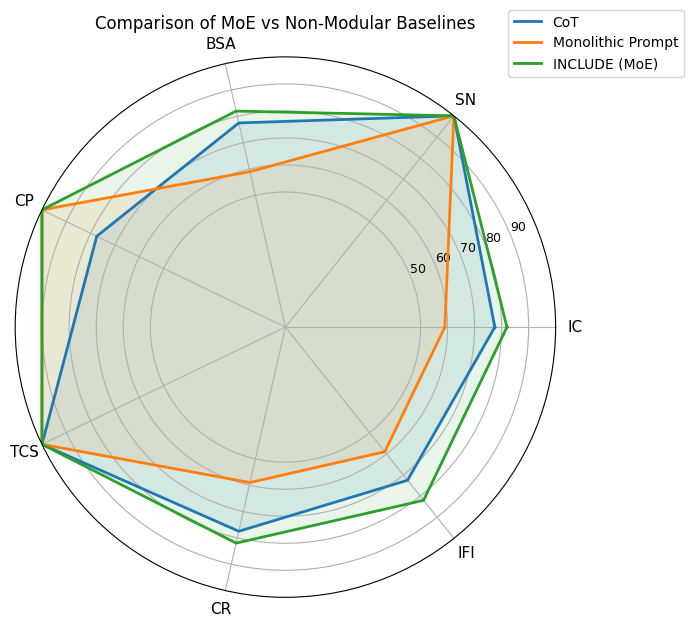

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Metrics
labels = ['IC', 'SN', 'BSA', 'CP', 'TCS', 'CR', 'IFI']
num_vars = len(labels)

# Data for ONLY the three models needed for reviewer concern
data = {
    'CoT':              [77.5, 100, 77.5, 77.5, 100, 77.5, 72.5],
    'Monolithic Prompt':[59, 100, 59,   100, 100, 59,   59],
    'INCLUDE (MoE)':    [82, 100, 82,   100, 100, 82,   82]
}

# Angles for radar
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False)
angles = np.concatenate((angles, [angles[0]]))

plt.figure(figsize=(7, 7))
ax = plt.subplot(111, polar=True)

for model_name, values in data.items():
    vals = values + [values[0]]
    ax.plot(angles, vals, label=model_name, linewidth=2)
    ax.fill(angles, vals, alpha=0.10)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11)

ax.set_ylim(0, 100)
ax.set_yticks([50, 60, 70, 80, 90])
ax.set_yticklabels(['50', '60', '70', '80', '90'], fontsize=9)

ax.set_title('Comparison of MoE vs Non-Modular Baselines', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1), fontsize=10)

plt.tight_layout()
plt.show()


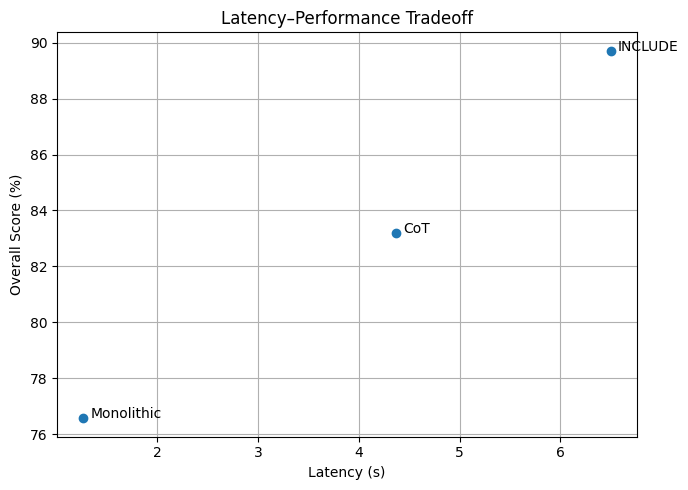

In [1]:
import matplotlib.pyplot as plt

# Data
models = ["CoT", "Monolithic", "INCLUDE"]
latency = [4.37, 1.27, 6.5]
overall = [83.21, 76.57, 89.71]

plt.figure(figsize=(7,5))
plt.scatter(latency, overall)

# Label points
for i, model in enumerate(models):
    plt.text(latency[i] + 0.07, overall[i], model)

plt.xlabel("Latency (s)")
plt.ylabel("Overall Score (%)")
plt.title("Latency–Performance Tradeoff")
plt.grid(True)
plt.tight_layout()
plt.show()
